In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv
/kaggle/input/notebooks/mohamedredaibrahim/student-performance-dataset/__results__.html
/kaggle/input/notebooks/mohamedredaibrahim/student-performance-dataset/__notebook__.ipynb
/kaggle/input/notebooks/mohamedredaibrahim/student-performance-dataset/__output__.json
/kaggle/input/notebooks/mohamedredaibrahim/student-performance-dataset/custom.css
/kaggle/input/notebooks/mohamedredaibrahim/student-performance-dataset/__results___files/__results___42_11.png
/kaggle/input/notebooks/mohamedredaibrahim/student-performance-dataset/__results___files/__results___41_1.png
/kaggle/input/notebooks/mohamedredaibrahim/student-performance-dataset/__results___files/__results___42_10.png
/kaggle/input/notebooks/mohamedredaibrahim/student-performance-dataset/__results___files/__results___31_1.png
/kaggle/input/notebooks/mohamedredaibrahim/student-performance-dataset/__results___files/__resu

In [3]:
df = pd.read_csv('/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv')

In [4]:
df.head()


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [5]:
df.shape

(1000, 12)

In [6]:
df.columns.tolist()

['student_id',
 'gender',
 'study_time_hours',
 'attendance_percent',
 'sleep_hours',
 'parental_education',
 'internet_access',
 'extracurricular_activities',
 'part_time_job',
 'previous_grade',
 'final_exam_score',
 'final_grade']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [8]:
df.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

In [9]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [10]:
df['parental_education'].value_counts(dropna=False)

parental_education
High School    356
Bachelors      308
Masters        184
NaN            102
PhD             50
Name: count, dtype: int64

In [11]:
df['parental_education'] = df['parental_education'].fillna(
    df['parental_education'].mode()[0]
)

In [12]:
df['parental_education'].isnull().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
print(df.shape)

(1000, 12)


In [16]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [17]:
print("Invalid attendance:",
      ((df['attendance_percent'] < 0) |
       (df['attendance_percent'] > 100)).sum())

print("Invalid sleep:",
      (df['sleep_hours'] < 0).sum())

print("Invalid previous grades:",
      (df['previous_grade'] < 0).sum())

print("Invalid exam scores:",
      (df['final_exam_score'] < 0).sum())

Invalid attendance: 0
Invalid sleep: 0
Invalid previous grades: 0
Invalid exam scores: 0


In [18]:
X = df.drop(columns=['student_id', 'final_grade'])
y = df['final_grade']

In [19]:
df['final_grade'].value_counts()

final_grade
B    354
A    284
C    261
D     89
F     12
Name: count, dtype: int64

In [20]:
df['final_grade'].value_counts(normalize=True)

final_grade
B    0.354
A    0.284
C    0.261
D    0.089
F    0.012
Name: proportion, dtype: float64

In [21]:
df['parental_education'].value_counts(dropna=False)

parental_education
High School    458
Bachelors      308
Masters        184
PhD             50
Name: count, dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [24]:
df['final_grade'].value_counts()

final_grade
B    354
A    284
C    261
D     89
F     12
Name: count, dtype: int64

In [25]:
df['parental_education'] = df['parental_education'].fillna(
    df['parental_education'].mode()[0]
)

In [26]:
df.isnull().sum()

student_id                    0
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df = df.drop_duplicates()

In [29]:
df['final_grade'].value_counts()

final_grade
B    354
A    284
C    261
D     89
F     12
Name: count, dtype: int64

In [30]:
df['final_grade'].value_counts(normalize=True) * 100

final_grade
B    35.4
A    28.4
C    26.1
D     8.9
F     1.2
Name: proportion, dtype: float64

In [31]:
X = df.drop(columns=['student_id', 'final_grade'])
y = df['final_grade']

In [32]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 10)
y shape: (1000,)


In [33]:
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print(categorical_features)

['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job']


In [34]:
numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print(numerical_features)

['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade', 'final_exam_score']


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

In [38]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'parental_education',
                                                   'internet_access',
                                                   'extracurricular_activities',
                                                   'part_time_job'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [39]:
y_pred = model.predict(X_test)

In [40]:
print(y_pred[:20])

['A' 'A' 'C' 'D' 'A' 'A' 'C' 'A' 'B' 'C' 'A' 'A' 'C' 'A' 'F' 'B' 'C' 'B'
 'A' 'C']


In [41]:
print(y_test.values[:20])

['A' 'A' 'C' 'B' 'A' 'A' 'D' 'A' 'B' 'B' 'A' 'A' 'C' 'A' 'D' 'B' 'C' 'B'
 'B' 'D']


In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.78


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.91      0.91      0.91        57
           B       0.77      0.80      0.79        71
           C       0.72      0.73      0.72        52
           D       0.69      0.50      0.58        18
           F       0.00      0.00      0.00         2

    accuracy                           0.78       200
   macro avg       0.62      0.59      0.60       200
weighted avg       0.78      0.78      0.78       200



In [44]:
df['final_grade'].value_counts()

final_grade
B    354
A    284
C    261
D     89
F     12
Name: count, dtype: int64

In [45]:
X = df.drop(columns=['student_id', 'final_grade'])
y = df['final_grade']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'parental_education',
                                                   'internet_access',
                                                   'extracurricular_activities',
                                                   'part_time_job'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [48]:
y_pred_logistic = logistic_model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:",
      accuracy_logistic)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic
))

Logistic Regression Accuracy: 0.78

Classification Report:
              precision    recall  f1-score   support

           A       0.91      0.91      0.91        57
           B       0.77      0.80      0.79        71
           C       0.72      0.73      0.72        52
           D       0.69      0.50      0.58        18
           F       0.00      0.00      0.00         2

    accuracy                           0.78       200
   macro avg       0.62      0.59      0.60       200
weighted avg       0.78      0.78      0.78       200



In [50]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'parental_education',
                                                   'internet_access',
                                                   'extracurricular_activities',
                                                   'part_time_job'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [51]:
y_pred_tree = decision_tree_model.predict(X_test)

In [52]:
accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

print("Decision Tree Accuracy:",
      accuracy_tree)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tree
))

Decision Tree Accuracy: 0.99

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        57
           B       1.00      0.99      0.99        71
           C       0.98      1.00      0.99        52
           D       1.00      0.94      0.97        18
           F       0.67      1.00      0.80         2

    accuracy                           0.99       200
   macro avg       0.93      0.99      0.95       200
weighted avg       0.99      0.99      0.99       200



In [53]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'parental_education',
                                                   'internet_access',
                                                   'extracurricular_activities',
                                                   'part_time_job'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [54]:
y_pred_rf = random_forest_model.predict(X_test)

In [55]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:",
      accuracy_rf)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf
))

Random Forest Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        57
           B       0.99      0.99      0.99        71
           C       0.98      0.98      0.98        52
           D       0.90      1.00      0.95        18
           F       0.00      0.00      0.00         2

    accuracy                           0.98       200
   macro avg       0.77      0.79      0.78       200
weighted avg       0.97      0.98      0.98       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [56]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_logistic,
        accuracy_tree,
        accuracy_rf
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.78
1,Decision Tree,0.99
2,Random Forest,0.98


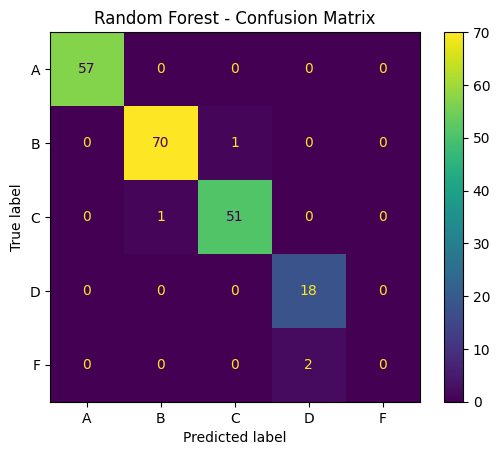

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [58]:
train_pred = decision_tree_model.predict(X_train)
test_pred = decision_tree_model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy : 0.99


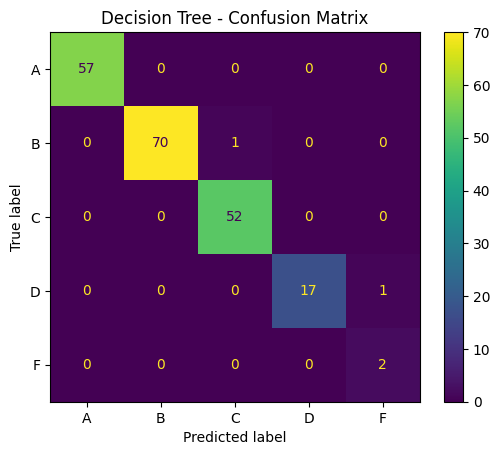

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [60]:
print(classification_report(
    y_test,
    y_pred_tree
))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00        57
           B       1.00      0.99      0.99        71
           C       0.98      1.00      0.99        52
           D       1.00      0.94      0.97        18
           F       0.67      1.00      0.80         2

    accuracy                           0.99       200
   macro avg       0.93      0.99      0.95       200
weighted avg       0.99      0.99      0.99       200



In [61]:
tree = decision_tree_model.named_steps['classifier']

feature_names = (
    decision_tree_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': tree.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
16,remainder__final_exam_score,1.0
0,categorical__gender_Female,0.0
1,categorical__gender_Male,0.0
3,categorical__parental_education_High School,0.0
2,categorical__parental_education_Bachelors,0.0
5,categorical__parental_education_PhD,0.0
6,categorical__internet_access_No,0.0
7,categorical__internet_access_Yes,0.0
4,categorical__parental_education_Masters,0.0
8,categorical__extracurricular_activities_No,0.0


In [62]:
train_pred = decision_tree_model.predict(X_train)
test_pred = decision_tree_model.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy :", accuracy_score(y_test, test_pred))

Training Accuracy: 1.0
Testing Accuracy : 0.99


In [63]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00        57
           B       1.00      0.99      0.99        71
           C       0.98      1.00      0.99        52
           D       1.00      0.94      0.97        18
           F       0.67      1.00      0.80         2

    accuracy                           0.99       200
   macro avg       0.93      0.99      0.95       200
weighted avg       0.99      0.99      0.99       200



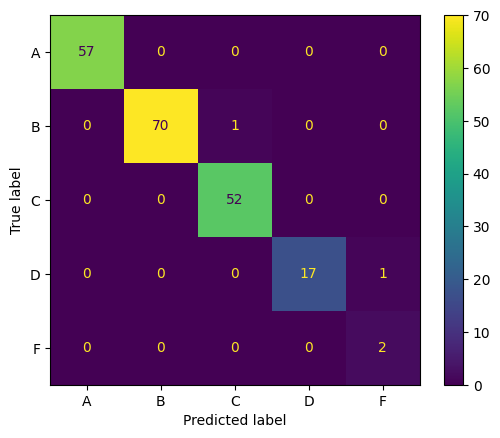

In [64]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree
)

plt.show()

In [65]:
importance_df.head(15)

,Feature,Importance
16,remainder__final_exam_score,1.0
0,categorical__gender_Female,0.0
1,categorical__gender_Male,0.0
3,categorical__parental_education_High School,0.0
2,categorical__parental_education_Bachelors,0.0
5,categorical__parental_education_PhD,0.0
6,categorical__internet_access_No,0.0
7,categorical__internet_access_Yes,0.0
4,categorical__parental_education_Masters,0.0
8,categorical__extracurricular_activities_No,0.0


In [66]:
import joblib

model_path = "/kaggle/working/student_performance_decision_tree.pkl"

joblib.dump(
    decision_tree_model,
    model_path
)

print("Model saved successfully!")
print(model_path)

Model saved successfully!
/kaggle/working/student_performance_decision_tree.pkl


In [67]:
import os

print(os.path.exists(model_path))
print(os.path.getsize(model_path), "bytes")

True
5955 bytes


In [68]:
loaded_model = joblib.load(model_path)

print("Model loaded successfully!")

Model loaded successfully!


In [69]:
loaded_predictions = loaded_model.predict(X_test)

loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

print("Loaded Model Accuracy:", loaded_accuracy)

Loaded Model Accuracy: 0.99


In [70]:
import joblib

In [71]:
model_path = "/kaggle/working/student_performance_decision_tree.pkl"

joblib.dump(decision_tree_model, model_path)

print("Model saved:", model_path)

Model saved: /kaggle/working/student_performance_decision_tree.pkl


In [72]:
import os

print(os.path.exists(model_path))

True
